# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

P = 42.65 Watt
De totale hoeveelheid toegevoegde warmte is 153.56 kJ
De hoeveelheid energie die nodig is om het water met 54 graden Celcius te laten stijgen is 107.24 kJ
De energie van het verdampte water bedraagt 46.3155572113712 kJ


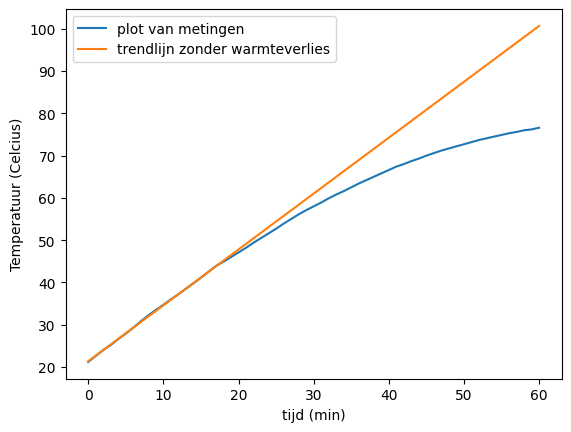

In [13]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.optimize import curve_fit

data = pd.read_csv("tempmetingen.csv", delimiter = ';')
t = data["t (min)"].to_numpy()
T = data["t (oC)"].to_numpy()

m_m = 0.8208 #kg
m_m_en_water_b=1.2929 #kg
m_m_en_water_e= 1.2749 #kg
m_w_b = m_m_en_water_b-m_m
m_w_e= m_m_en_water_e-m_m
m_w_gem=(m_w_b+m_w_e)/2
m_verd = m_w_b - m_w_e 
c_water = 4180 #J/kg*K

t_tot_verdamping= t[t<=18]
T_tot_verdamping =T[t<=18]

dT = max(T)-min(T)
def f(t,b,c):
    return b*t+c

popt, pcov = curve_fit(f,t_tot_verdamping,T_tot_verdamping)

b=popt[0]
c=popt[1]
x_tst = np.linspace(0,60,100)
y_tst=f(x_tst,*popt)

#b is de helling van de curvefit, deze wordt gebruikt om het vermogen te berekenen, maar moet wel nog naar seconden worden omgezet

a=b/60
P=m_w_gem*c_water*a

E_tot = P*3600
E_nodig_voor_stijging = m_w_gem *c_water*dT
E_verd = E_tot - E_nodig_voor_stijging

print("P =", round(P,2), "Watt")
print("De totale hoeveelheid toegevoegde warmte is", round(E_tot/1000,2), "kJ")
print("De hoeveelheid energie die nodig is om het water met 54 graden Celcius te laten stijgen is", round(E_nodig_voor_stijging/1000,2), "kJ")

print("De energie van het verdampte water bedraagt", E_verd/1000, "kJ")

plt.figure()

plt.plot(t,T, label = "plot van metingen")
plt.xlabel("tijd (min)")
plt.ylabel("Temperatuur (Celcius)")
plt.plot(x_tst,y_tst, label="trendlijn zonder warmteverlies")
plt.legend()
plt.show()




De totale hoeveelheid toegevoegde warmte is 153.56 kJ.

De hoeveelheid energie die nodig is om het water met 54 graden te laten stijgen is 107.24 kJ.

En de hoeveelheid energie in het verdampte water is dus 46.32 kJ
Dit lijkt dus wel op verdamping, aangezien er natuurlijk ook energie in de vorm van water verloren gaat aan de omgeving en de toegevoegde energie dus wat hoger is dan de benodigde energie, maar wel dezelfde orde van grootte heeft.

Een aanbeveling voor dit experiment is om de beker waar het water in zit te isoleren zodat er minder warmteverlies zal optreden en er een kleiner verschil zal zijn tussen de gebruikte energie en de benodigde energie. Een andere aanbeveling is om een roervlo te gebruiken in de maatbeker om temperatuurgradiënten te voorkomen. Ook zou het handig zijn om het vermogen dat is toegevoegd te meten, zodat deze waarde vast staat en niet hoeft worden benaderd door middel van een curve fit.